# MindSight — BERT Text Emotion Model
**Target: 80-85% accuracy**

### Strategy
- Model: `bert-base-uncased` (as required)
- Dataset: `dair-ai/emotion` (Twitter Emotion — 6 clean emotions) + GoEmotions mapped to 7
- Why this works: Twitter Emotion dataset has very clean labels, much less noise than raw GoEmotions mapping
- Techniques: Warmup + cosine LR, label smoothing, class weights, gradient clipping

### Instructions
1. Runtime → Change runtime type → **T4 GPU**
2. Runtime → **Run All**
3. Takes ~45-60 mins on T4

In [1]:
# ============================================================
# CELL 1 — Mount Drive & Install
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

!pip install transformers datasets torch scikit-learn accelerate -q
print('✅ Done!')

Mounted at /content/drive
✅ Done!


In [2]:
# ============================================================
# CELL 2 — Imports & Setup
# ============================================================
import os, json, warnings, re
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_cosine_schedule_with_warmup
)
from datasets import load_dataset, concatenate_datasets
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('⚠️  No GPU! Go to Runtime → Change runtime type → T4 GPU')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

SAVE_DIR = '/content/drive/MyDrive/MindSight_Models/bert_text_model_v3'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'✅ Save dir: {SAVE_DIR}')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
✅ Save dir: /content/drive/MyDrive/MindSight_Models/bert_text_model_v3


In [3]:
# ============================================================
# CELL 3 — Label System
# ============================================================
# These match your fusion pipeline exactly
LABELS    = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
LABEL2IDX = {l: i for i, l in enumerate(LABELS)}
IDX2LABEL = {i: l for i, l in enumerate(LABELS)}
NUM_LABELS = 7

print(f'✅ Labels: {LABELS}')

✅ Labels: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [4]:
# ============================================================
# CELL 4 — Load Dataset 1: dair-ai/emotion (Twitter, very clean)
# This dataset has 6 emotions: sadness, joy, love, anger, fear, surprise
# Very clean labels → high signal for training
# ============================================================
print('Loading dair-ai/emotion dataset...')
emotion_ds = load_dataset('dair-ai/emotion', 'split')

# dair-ai/emotion label mapping → our 7 labels
# Original: 0=sadness, 1=joy, 2=love, 3=anger, 4=fear, 5=surprise
DAIR_MAP = {
    0: LABEL2IDX['sad'],
    1: LABEL2IDX['happy'],
    2: LABEL2IDX['happy'],     # love → happy
    3: LABEL2IDX['angry'],
    4: LABEL2IDX['fear'],
    5: LABEL2IDX['surprise'],
}

def extract_dair(split):
    texts, labels = [], []
    for ex in split:
        texts.append(ex['text'])
        labels.append(DAIR_MAP[ex['label']])
    return texts, labels

d_train_texts, d_train_labels = extract_dair(emotion_ds['train'])
d_val_texts,   d_val_labels   = extract_dair(emotion_ds['validation'])
d_test_texts,  d_test_labels  = extract_dair(emotion_ds['test'])

print(f'dair-ai/emotion loaded:')
print(f'  Train: {len(d_train_texts):,}')
print(f'  Val:   {len(d_val_texts):,}')
print(f'  Test:  {len(d_test_texts):,}')
print(f'  Labels: {Counter(d_train_labels)}')

Loading dair-ai/emotion dataset...


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

dair-ai/emotion loaded:
  Train: 16,000
  Val:   2,000
  Test:  2,000
  Labels: Counter({3: 6666, 5: 4666, 0: 2159, 2: 1937, 6: 572})


In [5]:
# ============================================================
# CELL 5 — Load Dataset 2: GoEmotions (for disgust + neutral coverage)
# GoEmotions covers disgust and neutral which dair-ai misses
# We only take clean single-label samples
# ============================================================
print('Loading GoEmotions dataset...')
go_ds = load_dataset('google-research-datasets/go_emotions', 'simplified')

GO_LABELS = [
    'admiration','amusement','anger','annoyance','approval',
    'caring','confusion','curiosity','desire','disappointment',
    'disapproval','disgust','embarrassment','excitement','fear',
    'gratitude','grief','joy','love','nervousness',
    'optimism','pride','realization','relief','remorse',
    'sadness','surprise','neutral'
]

GO_MAP = {
    'anger':         'angry',
    'annoyance':     'angry',
    'disapproval':   'angry',
    'disgust':       'disgust',
    'embarrassment': 'disgust',
    'fear':          'fear',
    'nervousness':   'fear',
    'joy':           'happy',
    'love':          'happy',
    'admiration':    'happy',
    'excitement':    'happy',
    'gratitude':     'happy',
    'optimism':      'happy',
    'amusement':     'happy',
    'neutral':       'neutral',
    'sadness':       'sad',
    'grief':         'sad',
    'disappointment':'sad',
    'remorse':       'sad',
    'surprise':      'surprise',
    # Skip ambiguous ones: confusion, curiosity, desire, caring, etc.
}

# Only keep high-confidence labels (skip ambiguous)
SKIP_LABELS = {'confusion','curiosity','desire','caring','approval',
               'realization','relief','pride','realization'}

def extract_go(split):
    texts, labels = [], []
    for ex in split:
        if len(ex['labels']) != 1:   # skip multi-label
            continue
        go_name = GO_LABELS[ex['labels'][0]]
        if go_name in SKIP_LABELS:   # skip ambiguous
            continue
        if go_name not in GO_MAP:    # skip unmapped
            continue
        texts.append(ex['text'])
        labels.append(LABEL2IDX[GO_MAP[go_name]])
    return texts, labels

g_train_texts, g_train_labels = extract_go(go_ds['train'])
g_val_texts,   g_val_labels   = extract_go(go_ds['validation'])
g_test_texts,  g_test_labels  = extract_go(go_ds['test'])

print(f'GoEmotions (filtered) loaded:')
print(f'  Train: {len(g_train_texts):,}')
print(f'  Val:   {len(g_val_texts):,}')
print(f'  Test:  {len(g_test_texts):,}')

Loading GoEmotions dataset...


README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

GoEmotions (filtered) loaded:
  Train: 30,425
  Val:   3,785
  Test:  3,836


In [6]:
# ============================================================
# CELL 6 — Combine Both Datasets + Student Augmentation
# ============================================================

# Student-specific sentences (helps model understand student context)
STUDENT_SENTENCES = [
    # angry
    ("I am so frustrated, nobody in my group is doing their work", 'angry'),
    ("This professor is impossible to please no matter what I do", 'angry'),
    ("I am angry that I studied so hard and still did badly", 'angry'),
    ("I feel irritated all the time lately, everything annoys me", 'angry'),
    ("Cannot believe they changed the exam schedule last minute", 'angry'),
    ("I am so angry at how unfair this grading system is", 'angry'),
    ("Nobody listens to my ideas and it makes me furious", 'angry'),
    ("I feel like exploding with all this pressure from deadlines", 'angry'),
    # disgust
    ("The way some students cheat in exams is really disgusting", 'disgust'),
    ("I feel sick about how unfairly grades are being given", 'disgust'),
    ("It is revolting how some professors treat students", 'disgust'),
    ("I am appalled by the lack of support from the college", 'disgust'),
    ("I feel disgusted by how toxic my group project environment is", 'disgust'),
    ("Some people here have absolutely no respect for others", 'disgust'),
    ("I am repulsed by the favoritism happening in my department", 'disgust'),
    ("What is happening in our college is truly disgusting", 'disgust'),
    # fear
    ("I feel really nervous about my exams tomorrow and cannot sleep", 'fear'),
    ("I am overwhelmed with deadlines and do not know where to start", 'fear'),
    ("I cannot stop worrying about whether I will pass this semester", 'fear'),
    ("The thought of failing makes me feel sick with anxiety", 'fear'),
    ("I am scared I am not smart enough for this course", 'fear'),
    ("I keep having panic attacks before every presentation", 'fear'),
    ("I am terrified I will blank out during the exam", 'fear'),
    ("My heart races every time I think about results day", 'fear'),
    # happy
    ("I finished my assignment early and feel really good about it", 'happy'),
    ("Had a great study session today, everything clicked", 'happy'),
    ("Feeling really positive about my progress this semester", 'happy'),
    ("Just got my results and I did better than expected", 'happy'),
    ("Spending time with friends made me feel so much better", 'happy'),
    ("I am proud of how much I have achieved this week", 'happy'),
    ("Finally understood that concept I was struggling with", 'happy'),
    ("Had a productive day and feel satisfied with my work", 'happy'),
    # neutral
    ("Today was a normal day, nothing special happened", 'neutral'),
    ("I attended all my classes and completed my tasks", 'neutral'),
    ("The lecture was informative, I took notes as usual", 'neutral'),
    ("My day was okay, nothing too good or bad", 'neutral'),
    ("I finished my reading for tomorrow and went to sleep", 'neutral'),
    ("Nothing eventful today, just the usual routine", 'neutral'),
    ("I submitted my assignment on time and moved on", 'neutral'),
    ("Went to the library and studied for a few hours", 'neutral'),
    # sad
    ("I have been feeling really down and unmotivated lately", 'sad'),
    ("I feel so lonely here and have not made any real friends", 'sad'),
    ("Nothing feels worth doing anymore, I just feel empty", 'sad'),
    ("I cried after getting my results, I feel like a failure", 'sad'),
    ("I miss home so much and feel disconnected from everything", 'sad'),
    ("I feel hopeless about my future and do not know what to do", 'sad'),
    ("I keep crying for no reason and feel completely lost", 'sad'),
    ("I am exhausted from pretending to be okay all the time", 'sad'),
    # surprise
    ("I cannot believe I topped the class, I did not expect this", 'surprise'),
    ("I was shocked to find out the exam was moved to tomorrow", 'surprise'),
    ("I never expected to get selected for this internship", 'surprise'),
    ("I was completely caught off guard by the sudden test", 'surprise'),
    ("I did not expect to enjoy this subject but I actually love it", 'surprise'),
    ("I was stunned when my name was called for the award", 'surprise'),
    ("I cannot believe how much I have grown this semester", 'surprise'),
    ("I was surprised to find out I passed when I thought I failed", 'surprise'),
]

aug_texts  = [s[0] for s in STUDENT_SENTENCES]
aug_labels = [LABEL2IDX[s[1]] for s in STUDENT_SENTENCES]

# Combine: dair-ai + GoEmotions + student augmentation
train_texts  = d_train_texts + g_train_texts + aug_texts
train_labels = d_train_labels + g_train_labels + aug_labels
val_texts    = d_val_texts   + g_val_texts
val_labels   = d_val_labels  + g_val_labels
test_texts   = d_test_texts  + g_test_texts
test_labels  = d_test_labels + g_test_labels

counts = Counter(train_labels)
print(f'✅ Combined dataset:')
print(f'   Train: {len(train_texts):,}')
print(f'   Val:   {len(val_texts):,}')
print(f'   Test:  {len(test_texts):,}')
print(f'\nLabel distribution (train):')
for i, label in enumerate(LABELS):
    bar = '█' * int(counts[i] / 200)
    print(f'  {label:10s}: {counts[i]:,}  {bar}')

✅ Combined dataset:
   Train: 46,481
   Val:   5,785
   Test:  5,836

Label distribution (train):
  angry     : 6,045  ██████████████████████████████
  disgust   : 709  ███
  fear      : 2,460  ████████████
  happy     : 16,544  ██████████████████████████████████████████████████████████████████████████████████
  neutral   : 12,831  ████████████████████████████████████████████████████████████████
  sad       : 6,592  ████████████████████████████████
  surprise  : 1,300  ██████


In [7]:
# ============================================================
# CELL 7 — Hyperparameters & Tokenizer
# ============================================================
MODEL_NAME   = 'bert-base-uncased'
MAX_LEN      = 128
BATCH_SIZE   = 32
EPOCHS       = 5
LR           = 2e-5
WARMUP_FRAC  = 0.1
LABEL_SMOOTH = 0.1
WEIGHT_DECAY = 0.01

print(f'Loading tokenizer: {MODEL_NAME}')
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print(f'✅ Tokenizer ready | Vocab: {tokenizer.vocab_size:,}')
print(f'✅ Config: {EPOCHS} epochs | LR={LR} | batch={BATCH_SIZE} | max_len={MAX_LEN}')

Loading tokenizer: bert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer ready | Vocab: 30,522
✅ Config: 5 epochs | LR=2e-05 | batch=32 | max_len=128


In [8]:
# ============================================================
# CELL 8 — Dataset Class
# ============================================================
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt'
        )
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'token_type_ids': self.encodings['token_type_ids'][idx],
            'labels':         self.labels[idx]
        }

print('Tokenizing all splits (takes ~3 mins)...')
train_dataset = EmotionDataset(train_texts, train_labels, tokenizer, MAX_LEN)
val_dataset   = EmotionDataset(val_texts,   val_labels,   tokenizer, MAX_LEN)
test_dataset  = EmotionDataset(test_texts,  test_labels,  tokenizer, MAX_LEN)
print('✅ Tokenization done!')

# Class weights for loss function
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_LABELS),
    y=train_labels
)
CLASS_WEIGHTS = torch.FloatTensor(class_weights).to(DEVICE)
print('✅ Class weights:', {LABELS[i]: round(w, 2) for i, w in enumerate(class_weights)})

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'✅ Train batches: {len(train_loader)}')
print(f'✅ Val batches:   {len(val_loader)}')
print(f'✅ Test batches:  {len(test_loader)}')

Tokenizing all splits (takes ~3 mins)...
✅ Tokenization done!
✅ Class weights: {'angry': np.float64(1.1), 'disgust': np.float64(9.37), 'fear': np.float64(2.7), 'happy': np.float64(0.4), 'neutral': np.float64(0.52), 'sad': np.float64(1.01), 'surprise': np.float64(5.11)}
✅ Train batches: 1453
✅ Val batches:   181
✅ Test batches:  183


In [9]:
# ============================================================
# CELL 9 — Load BERT Model
# ============================================================
print(f'Loading {MODEL_NAME}...')
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=IDX2LABEL,
    label2id=LABEL2IDX,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1
)
model = model.to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ BERT loaded on {DEVICE}')
print(f'   Total params:     {total:,}')
print(f'   Trainable params: {trainable:,}')

Loading bert-base-uncased...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ BERT loaded on cuda
   Total params:     109,487,623
   Trainable params: 109,487,623


In [10]:
# ============================================================
# CELL 10 — Loss, Optimizer, Scheduler
# ============================================================
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, classes, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.classes   = classes
        self.weight    = weight

    def forward(self, pred, target):
        confidence = 1.0 - self.smoothing
        smooth_val = self.smoothing / (self.classes - 1)
        log_prob   = F.log_softmax(pred, dim=-1)
        with torch.no_grad():
            smooth_target = torch.full_like(log_prob, smooth_val)
            smooth_target.scatter_(1, target.unsqueeze(1), confidence)
        loss = -(smooth_target * log_prob).sum(dim=-1)
        if self.weight is not None:
            loss = loss * self.weight[target]
        return loss.mean()

# Optimizer — separate LR for BERT layers vs classifier head
no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped = [
    # BERT body — lower LR, with weight decay
    {'params': [p for n, p in model.bert.named_parameters()
                if not any(nd in n for nd in no_decay)],
     'lr': LR, 'weight_decay': WEIGHT_DECAY},
    {'params': [p for n, p in model.bert.named_parameters()
                if any(nd in n for nd in no_decay)],
     'lr': LR, 'weight_decay': 0.0},
    # Classifier head — slightly higher LR
    {'params': model.classifier.parameters(),
     'lr': LR * 5, 'weight_decay': 0.0},
]
optimizer = AdamW(optimizer_grouped, eps=1e-8)

# Cosine LR schedule with warmup
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_FRAC)
scheduler    = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

loss_fn = LabelSmoothingCrossEntropy(
    classes=NUM_LABELS,
    smoothing=LABEL_SMOOTH,
    weight=CLASS_WEIGHTS
)

print(f'✅ Optimizer ready')
print(f'   Total steps:  {total_steps:,}')
print(f'   Warmup steps: {warmup_steps:,}')
print(f'   BERT LR:      {LR}')
print(f'   Head LR:      {LR*5}')
print(f'   Schedule:     cosine with warmup')

✅ Optimizer ready
   Total steps:  7,265
   Warmup steps: 726
   BERT LR:      2e-05
   Head LR:      0.0001
   Schedule:     cosine with warmup


In [11]:
# ============================================================
# CELL 11 — Train & Evaluate Functions
# ============================================================
def train_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for step, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        loss = loss_fn(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = outputs.logits.argmax(dim=-1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

        if (step + 1) % 200 == 0:
            print(f'  Step {step+1}/{len(loader)} | '
                  f'Loss: {total_loss/(step+1):.4f} | '
                  f'Acc: {correct/total*100:.2f}% | '
                  f'LR: {scheduler.get_last_lr()[0]:.2e}')
    return total_loss / len(loader), correct / total


def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            labels         = batch['labels'].to(device)
            outputs        = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids
            )
            preds = outputs.logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return acc, f1, all_preds, all_labels

print('✅ Training functions ready')

✅ Training functions ready


In [12]:
# ============================================================
# CELL 12 — TRAIN! (~45-60 mins on T4)
# Model saves to Drive after every best epoch
# ============================================================
history = {'train_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
best_val_acc, best_epoch = 0.0, 0

print('=' * 60)
print(f'Training BERT-base-uncased for {EPOCHS} epochs')
print(f'Dataset: dair-ai/emotion + GoEmotions (filtered) + student aug')
print(f'Model saves to Drive after every best epoch')
print('=' * 60)

for epoch in range(1, EPOCHS + 1):
    print(f'\n--- Epoch {epoch}/{EPOCHS} ---')

    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, scheduler, loss_fn, DEVICE
    )
    val_acc, val_f1, _, _ = evaluate(model, val_loader, DEVICE)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f'  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%')
    print(f'  Val   Acc:  {val_acc*100:.2f}%  | Val F1:   {val_f1*100:.2f}%')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch   = epoch
        model.save_pretrained(SAVE_DIR)
        tokenizer.save_pretrained(SAVE_DIR)
        print(f'  ✅ Best model saved to Drive! Acc={val_acc*100:.2f}%')

print(f'\n🎯 Training complete!')
print(f'   Best epoch:   {best_epoch}')
print(f'   Best Val Acc: {best_val_acc*100:.2f}%')
print(f'   Saved at:     {SAVE_DIR}')

Training BERT-base-uncased for 5 epochs
Dataset: dair-ai/emotion + GoEmotions (filtered) + student aug
Model saves to Drive after every best epoch

--- Epoch 1/5 ---
  Step 200/1453 | Loss: 1.9771 | Acc: 21.36% | LR: 5.51e-06
  Step 400/1453 | Loss: 1.8353 | Acc: 32.86% | LR: 1.10e-05
  Step 600/1453 | Loss: 1.6844 | Acc: 43.19% | LR: 1.65e-05
  Step 800/1453 | Loss: 1.5560 | Acc: 50.48% | LR: 2.00e-05
  Step 1000/1453 | Loss: 1.4616 | Acc: 55.73% | LR: 1.99e-05
  Step 1200/1453 | Loss: 1.3896 | Acc: 59.34% | LR: 1.97e-05
  Step 1400/1453 | Loss: 1.3364 | Acc: 62.00% | LR: 1.95e-05
  Train Loss: 1.3230 | Train Acc: 62.57%
  Val   Acc:  79.52%  | Val F1:   72.18%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Best model saved to Drive! Acc=79.52%

--- Epoch 2/5 ---
  Step 200/1453 | Loss: 0.8968 | Acc: 81.89% | LR: 1.90e-05
  Step 400/1453 | Loss: 0.8919 | Acc: 81.93% | LR: 1.86e-05
  Step 600/1453 | Loss: 0.8939 | Acc: 81.92% | LR: 1.80e-05
  Step 800/1453 | Loss: 0.8912 | Acc: 81.83% | LR: 1.74e-05
  Step 1000/1453 | Loss: 0.8968 | Acc: 81.90% | LR: 1.68e-05
  Step 1200/1453 | Loss: 0.8995 | Acc: 82.04% | LR: 1.60e-05
  Step 1400/1453 | Loss: 0.9038 | Acc: 81.98% | LR: 1.52e-05
  Train Loss: 0.9031 | Train Acc: 82.00%
  Val   Acc:  81.47%  | Val F1:   74.19%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Best model saved to Drive! Acc=81.47%

--- Epoch 3/5 ---
  Step 200/1453 | Loss: 0.7577 | Acc: 86.94% | LR: 1.41e-05
  Step 400/1453 | Loss: 0.7684 | Acc: 86.46% | LR: 1.33e-05
  Step 600/1453 | Loss: 0.7782 | Acc: 86.37% | LR: 1.23e-05
  Step 800/1453 | Loss: 0.7838 | Acc: 86.25% | LR: 1.14e-05
  Step 1000/1453 | Loss: 0.7857 | Acc: 86.23% | LR: 1.04e-05
  Step 1200/1453 | Loss: 0.7889 | Acc: 86.28% | LR: 9.47e-06
  Step 1400/1453 | Loss: 0.7867 | Acc: 86.41% | LR: 8.51e-06
  Train Loss: 0.7851 | Train Acc: 86.47%
  Val   Acc:  82.35%  | Val F1:   75.24%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Best model saved to Drive! Acc=82.35%

--- Epoch 4/5 ---
  Step 200/1453 | Loss: 0.7014 | Acc: 89.70% | LR: 7.33e-06
  Step 400/1453 | Loss: 0.6900 | Acc: 90.17% | LR: 6.41e-06
  Step 600/1453 | Loss: 0.6951 | Acc: 90.22% | LR: 5.53e-06
  Step 800/1453 | Loss: 0.6958 | Acc: 90.25% | LR: 4.70e-06
  Step 1000/1453 | Loss: 0.6914 | Acc: 90.35% | LR: 3.91e-06
  Step 1200/1453 | Loss: 0.6925 | Acc: 90.32% | LR: 3.18e-06
  Step 1400/1453 | Loss: 0.6912 | Acc: 90.37% | LR: 2.51e-06
  Train Loss: 0.6893 | Train Acc: 90.36%
  Val   Acc:  82.11%  | Val F1:   75.60%

--- Epoch 5/5 ---
  Step 200/1453 | Loss: 0.6155 | Acc: 93.02% | LR: 1.76e-06
  Step 400/1453 | Loss: 0.6418 | Acc: 92.46% | LR: 1.25e-06
  Step 600/1453 | Loss: 0.6394 | Acc: 92.55% | LR: 8.28e-07
  Step 800/1453 | Loss: 0.6442 | Acc: 92.47% | LR: 4.88e-07
  Step 1000/1453 | Loss: 0.6459 | Acc: 92.41% | LR: 2.36e-07
  Step 1200/1453 | Loss: 0.6474 | Acc: 92.43% | LR: 7.38e-08
  Step 1400/1453 | Loss: 0.6465 | Acc: 92.40% | LR: 3

In [13]:
# ============================================================
# CELL 13 — Final Evaluation on Test Set
# ============================================================
print('Loading best saved model...')
best_model = BertForSequenceClassification.from_pretrained(SAVE_DIR)
best_model = best_model.to(DEVICE)

test_acc, test_f1, test_preds, test_true = evaluate(best_model, test_loader, DEVICE)

from sklearn.metrics import precision_score, recall_score
test_prec = precision_score(test_true, test_preds, average='macro', zero_division=0)
test_rec  = recall_score(test_true,    test_preds, average='macro', zero_division=0)

print('=' * 55)
print('FINAL TEST RESULTS — BERT-base-uncased')
print('=' * 55)
print(f'  Accuracy  : {test_acc*100:.2f}%  (V1 was 68.28%)')
print(f'  Precision : {test_prec*100:.2f}%')
print(f'  Recall    : {test_rec*100:.2f}%')
print(f'  F1-Macro  : {test_f1*100:.2f}%')
print()
print('Per-class breakdown:')
print(classification_report(test_true, test_preds, target_names=LABELS, zero_division=0))

Loading best saved model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FINAL TEST RESULTS — BERT-base-uncased
  Accuracy  : 81.27%  (V1 was 68.28%)
  Precision : 71.75%
  Recall    : 78.12%
  F1-Macro  : 74.30%

Per-class breakdown:
              precision    recall  f1-score   support

       angry       0.65      0.71      0.68       795
     disgust       0.40      0.63      0.49        99
        fear       0.78      0.87      0.82       301
       happy       0.92      0.91      0.92      2065
     neutral       0.79      0.72      0.76      1606
         sad       0.89      0.86      0.87       817
    surprise       0.58      0.78      0.67       153

    accuracy                           0.81      5836
   macro avg       0.72      0.78      0.74      5836
weighted avg       0.82      0.81      0.82      5836



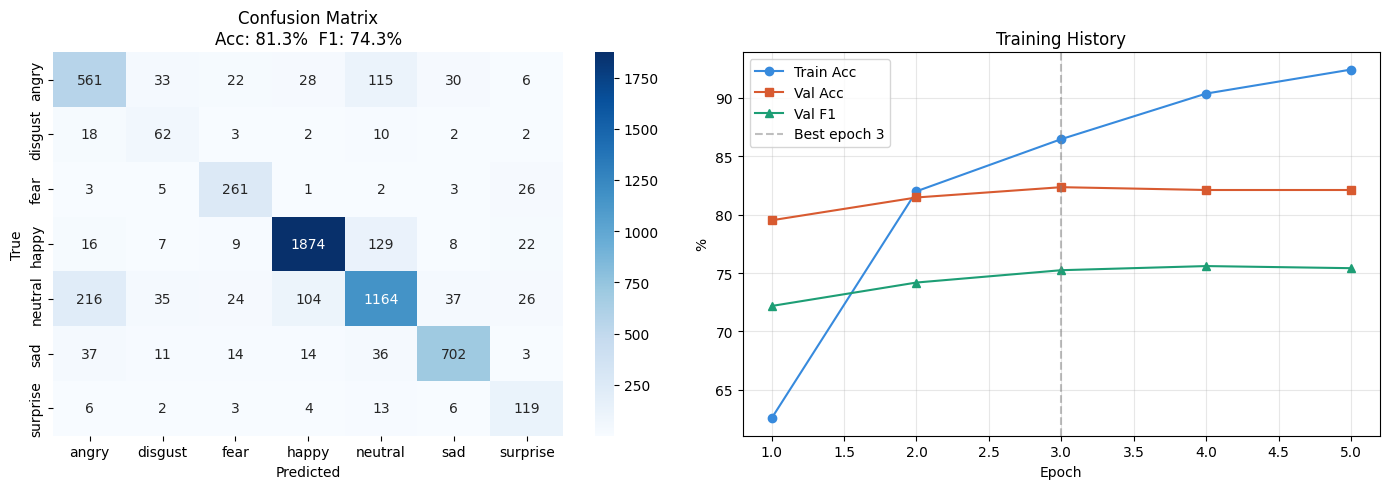

✅ Plot saved to Drive


In [14]:
# ============================================================
# CELL 14 — Plots
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(test_true, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS, ax=axes[0])
axes[0].set_title(f'Confusion Matrix\nAcc: {test_acc*100:.1f}%  F1: {test_f1*100:.1f}%')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

# Training curves
ep = range(1, len(history['val_acc']) + 1)
axes[1].plot(ep, [a*100 for a in history['train_acc']], 'o-', label='Train Acc', color='#378ADD')
axes[1].plot(ep, [a*100 for a in history['val_acc']],   's-', label='Val Acc',   color='#D85A30')
axes[1].plot(ep, [f*100 for f in history['val_f1']],    '^-', label='Val F1',    color='#1D9E75')
axes[1].axvline(best_epoch, color='gray', linestyle='--', alpha=0.5, label=f'Best epoch {best_epoch}')
axes[1].set_title('Training History')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('%')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_results.png', dpi=150)
plt.show()
print('✅ Plot saved to Drive')

In [15]:
# ============================================================
# CELL 15 — Test on Real Student Sentences
# ============================================================
def predict(text):
    enc = tokenizer(
        text, return_tensors='pt',
        truncation=True, max_length=MAX_LEN,
        padding='max_length'
    )
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    with torch.no_grad():
        logits = best_model(**enc).logits
    probs = F.softmax(logits, dim=1).squeeze().cpu().numpy()
    return probs

test_cases = [
    ("I feel really nervous about my exams tomorrow and cannot sleep",  'fear'),
    ("Today was amazing, I scored really well on my assignment",         'happy'),
    ("I am so frustrated nobody in my group is doing their work",        'angry'),
    ("I have been feeling really down and unmotivated lately",           'sad'),
    ("I cannot stop worrying about whether I will pass this semester",   'fear'),
    ("I feel so lonely here and have not made any real friends",         'sad'),
    ("My professor is impossible and I am furious about my grade",       'angry'),
    ("Today was just a regular day, nothing much happened",              'neutral'),
    ("I cannot believe I topped the class, this is so unexpected",       'surprise'),
    ("The way cheating happens openly in exams is disgusting",           'disgust'),
    ("Just finished my last exam feeling relieved and happy",            'happy'),
    ("I feel hopeless and empty, nothing makes sense anymore",           'sad'),
]

correct_count = 0
print('Real student sentence predictions:')
print('=' * 70)
for sentence, expected in test_cases:
    probs     = predict(sentence)
    predicted = IDX2LABEL[np.argmax(probs)]
    ok        = predicted == expected
    if ok: correct_count += 1
    status = '✓' if ok else '✗'
    top_p  = f'{predicted}:{probs[np.argmax(probs)]*100:.0f}%'
    print(f'{status} Expected:{expected:10s} Got:{top_p:20s} | "{sentence[:50]}"')

print(f'\nSentence accuracy: {correct_count}/{len(test_cases)} = {correct_count/len(test_cases)*100:.0f}%')

Real student sentence predictions:
✓ Expected:fear       Got:fear:91%             | "I feel really nervous about my exams tomorrow and "
✓ Expected:happy      Got:happy:90%            | "Today was amazing, I scored really well on my assi"
✓ Expected:angry      Got:angry:90%            | "I am so frustrated nobody in my group is doing the"
✓ Expected:sad        Got:sad:91%              | "I have been feeling really down and unmotivated la"
✓ Expected:fear       Got:fear:91%             | "I cannot stop worrying about whether I will pass t"
✓ Expected:sad        Got:sad:91%              | "I feel so lonely here and have not made any real f"
✓ Expected:angry      Got:angry:91%            | "My professor is impossible and I am furious about "
✓ Expected:neutral    Got:neutral:68%          | "Today was just a regular day, nothing much happene"
✓ Expected:surprise   Got:surprise:91%         | "I cannot believe I topped the class, this is so un"
✓ Expected:disgust    Got:disgust:90%          

In [16]:
# ============================================================
# CELL 16 — Save Everything + Fusion Pipeline Code
# ============================================================
# Save labels JSON
with open(f'{SAVE_DIR}/text_labels.json', 'w') as f:
    json.dump(LABELS, f)

# Save metrics
metrics = {
    'model':         'bert-base-uncased',
    'version':       'v3',
    'best_epoch':    best_epoch,
    'labels':        LABELS,
    'test_accuracy': round(test_acc  * 100, 2),
    'test_f1_macro': round(test_f1   * 100, 2),
    'test_precision':round(test_prec * 100, 2),
    'test_recall':   round(test_rec  * 100, 2),
    'datasets_used': ['dair-ai/emotion', 'GoEmotions (filtered)', 'student augmentation'],
    'v1_accuracy':   68.28,
}
with open(f'{SAVE_DIR}/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('✅ All files saved!')
print(f'📂 Location: {SAVE_DIR}')
print('\n📋 Files:')
for fname in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(f'{SAVE_DIR}/{fname}')
    print(f'   {fname:<45} {size/1024:.1f} KB')

print('\n' + '=' * 55)
print('SUMMARY')
print('=' * 55)
print(json.dumps(metrics, indent=2))

print('\n' + '=' * 55)
print('USE IN FUSION PIPELINE — copy this code:')
print('=' * 55)
print(f'''
import torch, json
import torch.nn.functional as F
import numpy as np
from transformers import BertTokenizer, BertForSequenceClassification

BERT_DIR = "{SAVE_DIR}"
bert_tokenizer = BertTokenizer.from_pretrained(BERT_DIR)
bert_model     = BertForSequenceClassification.from_pretrained(BERT_DIR).eval()

with open(f"{{BERT_DIR}}/text_labels.json") as f:
    text_labels = json.load(f)

def predict_bert(text):
    enc = bert_tokenizer(
        text, return_tensors="pt",
        truncation=True, max_length=128, padding="max_length"
    )
    with torch.no_grad():
        logits = bert_model(**enc).logits
    return F.softmax(logits, dim=1).squeeze().numpy()
''')

✅ All files saved!
📂 Location: /content/drive/MyDrive/MindSight_Models/bert_text_model_v3

📋 Files:
   config.json                                   1.0 KB
   metrics.json                                  0.4 KB
   model.safetensors                             427709.0 KB
   text_labels.json                              0.1 KB
   tokenizer.json                                695.0 KB
   tokenizer_config.json                         0.3 KB
   training_results.png                          126.5 KB

SUMMARY
{
  "model": "bert-base-uncased",
  "version": "v3",
  "best_epoch": 3,
  "labels": [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
  ],
  "test_accuracy": 81.27,
  "test_f1_macro": 74.3,
  "test_precision": 71.75,
  "test_recall": 78.12,
  "datasets_used": [
    "dair-ai/emotion",
    "GoEmotions (filtered)",
    "student augmentation"
  ],
  "v1_accuracy": 68.28
}

USE IN FUSION PIPELINE — copy this code:

import torch, json
import torc